# El radón de Minnesota, en tres modelos

919 mediciones de radón en viviendas de 85 condados de Minnesota. Son los datos de _Gelman
y Hill_. Llevan veinte años como ejemplo de modelo jerárquico (tienes la fuente exacta al final del notebook).

El radón es un gas radiactivo. Sale del suelo. La EPA recomienda actuar por encima de
4 pCi/L.

La pregunta: **¿cuánto radón cabe esperar en una casa de un condado concreto?**

Responderemos a esta pregunta con un modelo de regresión, pero lo plantearemos de tres formas diferentes:

1. Un nivel común para todos los condados (incertecept), en OLS y en bayesiano.
2. Un nivel propio para cada condado.
3. El jerárquico: los condados comparten información.

Incluiremos la diagnosis del muestreo bayesiano para asegurar convergencias.

**Observación.** El conjunto de datos que propongo no es directamente el de Gelman y Hill,
sino el que usa PyMC en sus ejemplos, que tiene ya mucho preprocesado hecho. La
única razón por la que no te llevo directamente al ejemplo de PyMC, y te propongo este
notebook, es porque creo que ellos se meten en detalles demasiado complejos
para estar dando primeros pasos en inferencia bayesiana.


---

**Cómo ejecutarlo.** En Google Colab, la primera celda instala lo necesario. Los datos se leen
por URL. Si Colab pide reiniciar, reinicia y vuelve a empezar. En local hacen falta
`numpy`, `pandas`, `matplotlib`, `statsmodels`, `pymc` y `arviz`. Si quieres ejecutar en local,
tendrás que tener un compilador de C++ o cambiar el código para que PyMC muestree con su librería
numpyro.

In [1]:
# En Colab: instala lo que falta. En local no hace nada: se da por hecho el entorno.
try:
    import google.colab  # noqa: F401

    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB:
    %pip install -q "numpy>=1.26,<2.5" "pymc>=5.15,<6" "arviz>=0.23,<1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 9.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import statsmodels.api as sm

ACENTO = "#800080"
GRISES = ["#000000", "#4A4A4A", "#7A7A7A", "#AAAAAA"]

plt.rcParams.update({
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E6D6E6",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler("color", GRISES),
    "axes.titlecolor": ACENTO,
    "figure.dpi": 110,
    "font.size": 13,
})

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

/usr/local/lib/python3.13/dist-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## 1. Los datos

Cada fila es una vivienda. Usamos cuatro columnas:

- `log_radon`: logaritmo de la medición, en pCi/L.
- `floor`: 0 si se midió en el sótano, 1 si en la planta baja.
- `county` y `county_code`: el condado, con nombre y con índice de 0 a 84.

Modelizamos el logaritmo de la medición, no la medición directamente. Buscamos un efecto multiplicativo. La idea es que los factores que incluyamos en la regresión afecten a fracciones de todo el radón que llegue a la casa, no a cantidades fijas.

In [3]:
# El fichero de Gelman, leído del repositorio de ejemplos de PyMC, ya procesado
URL_DATOS = (
    "https://raw.githubusercontent.com/pymc-devs/pymc-examples/"
    "2026.02.0/examples/data/radon.csv"
)

df = pd.read_csv(URL_DATOS)[["county", "county_code", "floor", "log_radon"]]

floor = df["floor"].values
log_radon = df["log_radon"].values
county_idx = df["county_code"].values
n_condados = df["county_code"].nunique()

print(f"{len(df)} mediciones en {n_condados} condados")
df.head()

919 mediciones en 85 condados


,county,county_code,floor,log_radon
0,AITKIN,0,1.0,0.832909
1,AITKIN,0,0.0,0.832909
2,AITKIN,0,0.0,1.098612
3,AITKIN,0,0.0,0.095310
4,ANOKA,1,0.0,1.163151


Muestro estadísticos generales. Algunos saldrán más adelante.

In [8]:
df.describe()

,county_code,floor,log_radon
count,919.000000,919.000000,919.000000
mean,42.523395,0.166485,1.264779
std,25.674841,0.372719,0.819355
min,0.000000,0.000000,-2.302585
25%,20.000000,0.000000,0.693147
50%,43.000000,0.000000,1.308333
75%,69.000000,0.000000,1.808289
max,84.000000,1.000000,3.877432


Y así queda la distribución de la variable objetivo (ya con logaritmo).

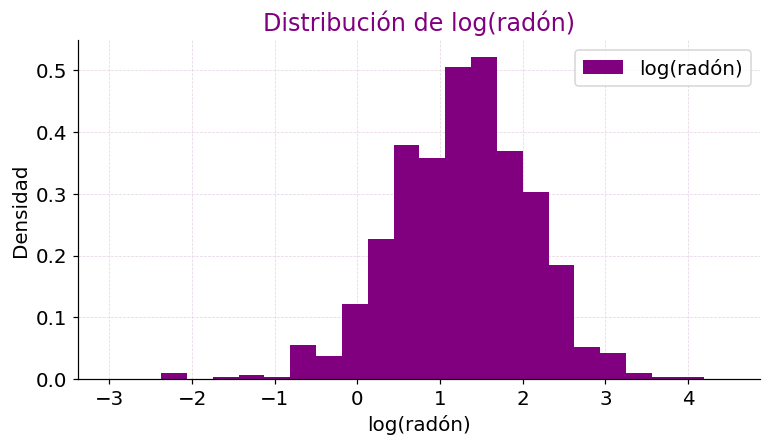

In [6]:
bordes = np.linspace(-3, 4.5, 25)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["log_radon"], bins=bordes, density=True, color=ACENTO, label="log(radón)")
ax.set_xlabel("log(radón)")
ax.set_ylabel("Densidad")
ax.legend()
ax.set_title("Distribución de log(radón)")
plt.show()

### El sótano da más radón que la planta baja

El gas sube desde el suelo. Por eso el modelo lleva un coeficiente para la planta.

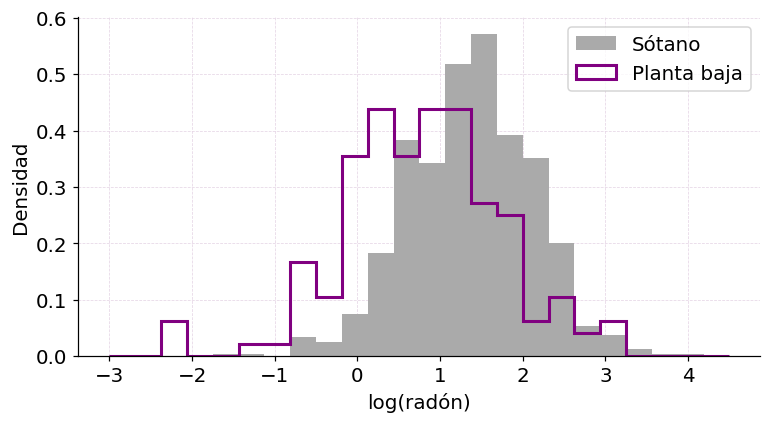

In [4]:
# density=True: hay 766 mediciones en sótano y 153 en planta baja.
bordes = np.linspace(-3, 4.5, 25)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_radon[floor == 0], bins=bordes, density=True, color="#AAAAAA", label="Sótano")
ax.hist(log_radon[floor == 1], bins=bordes, density=True, histtype="step",
        color=ACENTO, linewidth=2, label="Planta baja")
ax.set_xlabel("log(radón)")
ax.set_ylabel("Densidad")
ax.legend()
plt.show()

## 2. Modelo 1: pooled. Un nivel común para todos

Una recta, sin condados:

$$\log(\text{radón}_i) = \alpha + \beta_1 \cdot \text{planta}_i + \varepsilon_i$$

En el libro de Gelman, a este modelo se le llama _pooled_.

Primero, en OLS.

In [7]:
ols = sm.OLS(df["log_radon"], sm.add_constant(df[["floor"]])).fit()

pd.DataFrame({
    "Coeficiente": ols.params,
    "IC 2,5%": ols.conf_int()[0],
    "IC 97,5%": ols.conf_int()[1],
    "p-valor": ols.pvalues,
}).round(3)

,Coeficiente,"IC 2,5%","IC 97,5%",p-valor
const,1.362,1.306,1.418,0.0
floor,-0.586,-0.724,-0.449,0.0


### El mismo modelo, en bayesiano

Ahora hay que escribir las prioris. Sus escalas salen de la variable: `log_radon` tiene
desviación típica 0,82.

- $\alpha \sim \mathcal{N}(0, 2)$: el nivel base.
- $\beta_1 \sim \mathcal{N}(0, 1)$: el efecto de la planta, sin forzar que sea negativo ni positivo.
- $\sigma \sim \text{Exp}(1)$: la variación entre viviendas.

In [13]:
with pm.Model() as modelo_pooled:
    alpha = pm.Normal("alpha", mu=0, sigma=2)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    sigma = pm.Exponential("sigma", 1)

    y_obs = pm.Normal("y_obs", mu=alpha + beta1 * floor, sigma=sigma, observed=log_radon)

### Antes de ajustar, simulamos desde la priori

Generamos radón sin mirar los datos y lo pasamos a pCi/L. El objetivo es comprobar que la priori es creíble.

Paso a valores reales tomando la exponencial* y luego muestro en logaritmo decimal, que es más intuitivo que el natural para el gráfico.

**Observación.** La transformación logaritmo que hizo PyMC pasó por sumar 0,1 a las mediciones y evitar 3 mediciones con valor 0. No tengo en cuenta esto en esta conversión, así que queda solo como aproximación.

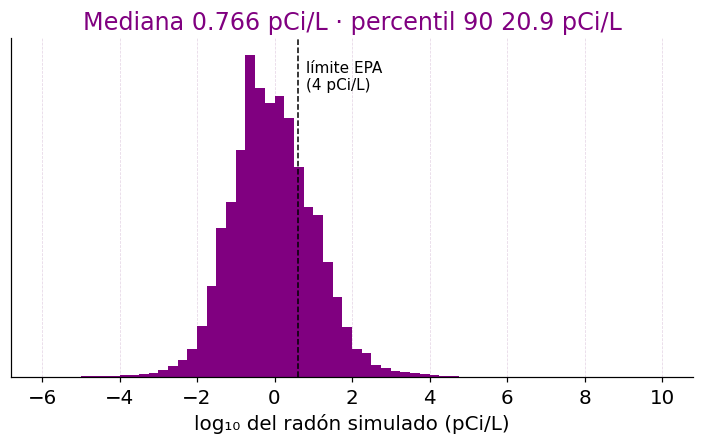

In [14]:
def pintar_priori(priori):
    # Histograma del radón simulado desde la priori, en pCi/L.
    radon = np.exp(priori.prior_predictive["y_obs"].values.reshape(-1))
    p50, p90 = np.percentile(radon, [50, 90])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(np.log10(radon), bins=np.linspace(-6, 10, 65), color=ACENTO)
    ax.axvline(np.log10(4), color="black", linestyle="--", linewidth=1)
    ax.text(np.log10(4) + 0.2, ax.get_ylim()[1] * 0.85, "límite EPA\n(4 pCi/L)", fontsize=10)
    ax.set_xlabel("log₁₀ del radón simulado (pCi/L)")
    ax.set_yticks([])
    ax.set_title(f"Mediana {p50:.3g} pCi/L · percentil 90 {p90:.3g} pCi/L")
    plt.show()


with modelo_pooled:
    priori_pooled = pm.sample_prior_predictive(draws=500, random_seed=SEMILLA)

pintar_priori(priori_pooled)

La mediana queda por debajo de 1 pCi/L. El percentil 90 ronda los 20. La cola es amplia,
pero los órdenes de magnitud son plausibles.

**Pruébalo tú.** Cambia `sigma=2` por `sigma=10` en el `alpha` del modelo. Ejecuta de
nuevo las dos celdas. Mira dónde acaba el percentil 90.

In [18]:
with modelo_pooled:
    idata_pooled = pm.sample(
        draws=1000, tune=1000, chains=4, random_seed=SEMILLA, progressbar=True
    )

Output()

### OLS y bayesiano dan los mismos números

Con 919 datos, la priori pesa poco. La media de la posteriori cae sobre OLS pero el  valor que aporta el bayesiano es que
añade la distribución completa de cada parámetro.

In [19]:
resumen = az.summary(idata_pooled, var_names=["alpha", "beta1", "sigma"])

pd.DataFrame({
    "OLS": [ols.params["const"], ols.params["floor"], np.sqrt(ols.scale)],
    "Bayesiano (media)": resumen["mean"].values,
    "HDI 3%": resumen["hdi_3%"].values,
    "HDI 97%": resumen["hdi_97%"].values,
}, index=["alpha / const", "beta1 / floor", "sigma"]).round(3)

,OLS,Bayesiano (media),HDI 3%,HDI 97%
alpha / const,1.362,1.362,1.307,1.416
beta1 / floor,-0.586,-0.583,-0.718,-0.455
sigma,0.790,0.791,0.755,0.824


### Pero los condados no son iguales

El Modelo 1 da un solo nivel para todo Minnesota. Miramos la media de cada condado.

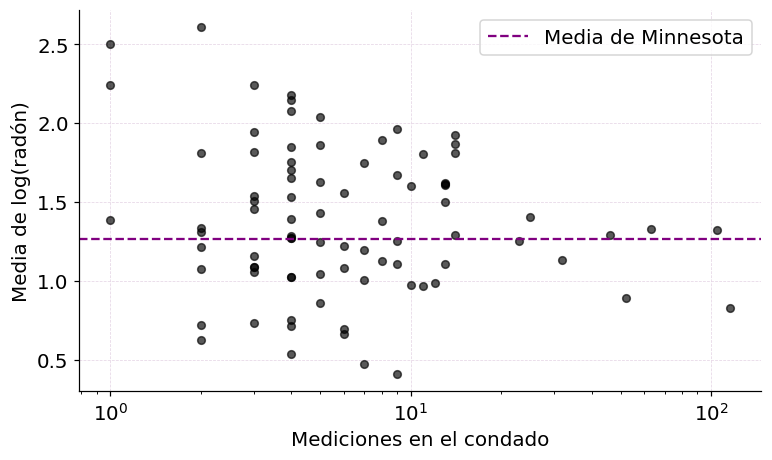

22 condados tienen 3 mediciones o menos. ST LOUIS tiene 116.


In [20]:
n_obs = np.bincount(county_idx)
media_condado = df.groupby("county_code")["log_radon"].mean().values
nombres = df.groupby("county_code")["county"].first().values

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(n_obs, media_condado, color="black", s=25, alpha=0.65)
ax.axhline(log_radon.mean(), color=ACENTO, linestyle="--", linewidth=1.5,
           label="Media de Minnesota")
ax.set_xscale("log")
ax.set_xlabel("Mediciones en el condado")
ax.set_ylabel("Media de log(radón)")
ax.legend()
plt.show()

print(f"{(n_obs <= 3).sum()} condados tienen 3 mediciones o menos. ST LOUIS tiene {n_obs.max()}.")

Las medias van de 0,4 a 2,6. Los condados son distintos. Un único $\alpha$ no los recoge. La solución pasa por usar varios $\alpha$, varios intercept.

Pero encontraremos otra dificultad.

Los puntos más dispersos están a la izquierda. Son condados con muy pocas mediciones y esto va a dar problemas: las predicciones serán inciertas.

## 3. Modelo 2: unpooled. Un nivel por condado

Cada condado tiene su $\alpha$. Son 85. La pendiente y $\sigma$ se comparten. En el código
cambia una cosa: `shape=n_condados`.

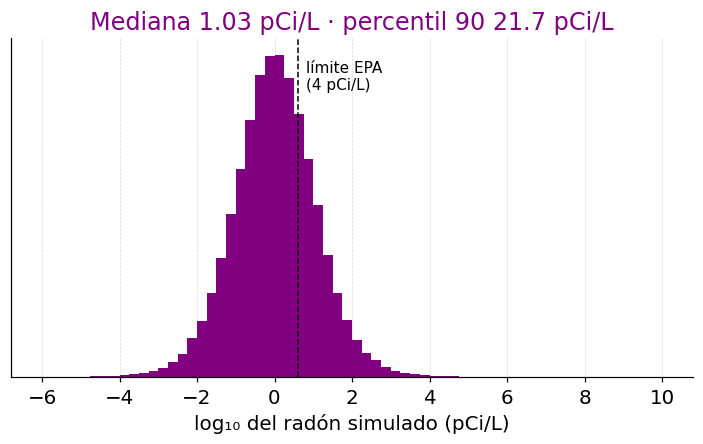

In [21]:
with pm.Model() as modelo_unpooled:
    alpha = pm.Normal("alpha", mu=0, sigma=2, shape=n_condados)  # un alpha por condado
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    sigma = pm.Exponential("sigma", 1)

    y_obs = pm.Normal(
        "y_obs", mu=alpha[county_idx] + beta1 * floor, sigma=sigma, observed=log_radon
    )

    priori_unpooled = pm.sample_prior_predictive(draws=500, random_seed=SEMILLA)

pintar_priori(priori_unpooled)

La priori sale parecida a la del Modelo 1. Ajustamos.

In [22]:
with modelo_unpooled:
    idata_unpooled = pm.sample(
        draws=1000, tune=1000, chains=4, random_seed=SEMILLA, progressbar=False
    )

### Los niveles extremos son de condados con poca muestra

En el siguiente gráfico cada punto es un condado. El eje vertical es la media de su $\alpha$ en la posteriori (recuerda que la posteriori es una distribución, por eso tomamos la media).

Etiqueto los dos más bajos y los dos más altos (siguiendo el ejemplo de A. Gelman), con sus mediciones entre paréntesis. La interpretación del gráfico viene después

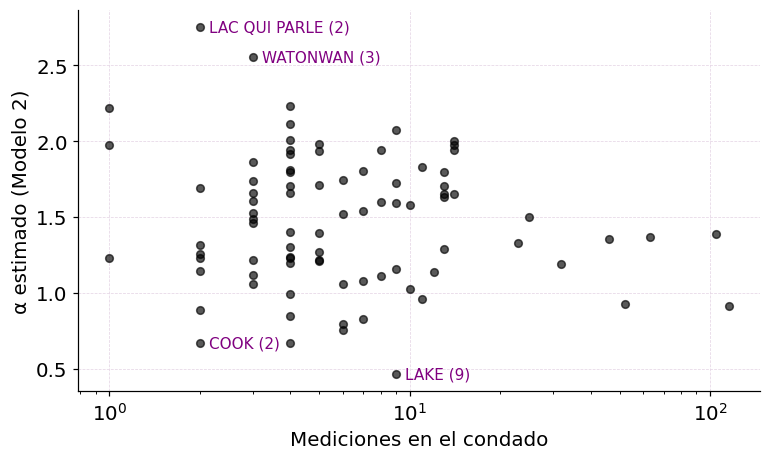

In [23]:
alpha_unpooled = idata_unpooled.posterior["alpha"].mean(("chain", "draw")).values
extremos = np.argsort(alpha_unpooled)[[0, 1, -2, -1]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(n_obs, alpha_unpooled, color="black", s=25, alpha=0.65)
for c in extremos:
    ax.annotate(f"{nombres[c]} ({n_obs[c]})", (n_obs[c], alpha_unpooled[c]),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=10, color=ACENTO)
ax.set_xscale("log")
ax.set_xlabel("Mediciones en el condado")
ax.set_ylabel("α estimado (Modelo 2)")
plt.show()

LAC QUI PARLE sale el condado con más radón de Minnesota. No ponemos en duda que sea verdaderamente alto, pero solo tiene dos casas medidas: es una muestra muy baja para aceptar que sea _tan_ alto.

WATONWAN sale segundo, con tres. Por abajo, COOK tiene dos. De nuevo, muestras demasiado pequeñas.

El modelo se cree esas pocas casas. Si midieron alto, el condado entero sale alto. Los
otros 84 condados saben qué niveles son plausibles. Este modelo no los mira.

## 4. Modelo 3: _partially pooled_. Los condados se prestan información

Los 85 niveles salen de una distribución común. Su media y su dispersión se estiman.

Esto Gelman lo llama _partially pooled._ Creo que normalmente en español lo llamamos jerárquico.

$$
\begin{aligned}
y_i &\sim \mathcal{N}(\alpha_{c[i]} + \beta_1 x_i, \; \sigma^2) \\[4pt]
\alpha_c &\sim \mathcal{N}(\mu_\alpha, \sigma_\alpha^2) \\[4pt]
\mu_\alpha &\sim \mathcal{N}(0, 2^2), \qquad \sigma_\alpha \sim \text{Exp}(1)
\end{aligned}
$$

La interpretación es compleja, pero la sintaxis con respecto al Modelo 2 es solo cambiar una línea.

La idea es que las predicciones, como siempre en bayesiano, van a tener una distribución. Igual que en el caso 2, la distribución variará por condado pero esta distribución por condado se calcula desde los datos. Es decir, no doy la priori sobre el intercept, como he hecho antes, sino que la doy sobre la distribución del intercept. La distribución del intercept se calcula con los datos. Esto dará al modelo mucha más estabilidad (cuando los condados tengan poca muestra, los datos extremos no tirarán con tanta fuerza porque el modelo sabrá que los datos no informan tanto como en un condado con mucha meustra).

Puedes comprobar también su priori. Sale como la del Modelo 2, con la cola algo más larga.
Aquí no la repetimos.

In [24]:
with pm.Model() as modelo_jerarquico:
    mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=2)
    sigma_alpha = pm.Exponential("sigma_alpha", 1)

    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, shape=n_condados)  # <—
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    sigma = pm.Exponential("sigma", 1)

    y_obs = pm.Normal(
        "y_obs", mu=alpha[county_idx] + beta1 * floor, sigma=sigma, observed=log_radon
    )

    idata_jerarquico = pm.sample(
        draws=1000, tune=1000, chains=4, target_accept=0.95,
        random_seed=SEMILLA, progressbar=False,
    )

Los tres modelos son el mismo. Cambia la restricción sobre los $\alpha_c$:

- **Modelo 1**: todos iguales. Equivale a $\sigma_\alpha = 0$.
- **Modelo 2**: sin relación entre ellos. Equivale a $\sigma_\alpha = \infty$.
- **Modelo 3**: $\sigma_\alpha$ se estima con los datos.



### Los condados con pocos datos se acercan a la media

El mismo gráfico de antes. Punto negro: Modelo 2. Círculo morado: Modelo 3. La línea gris
une los dos.

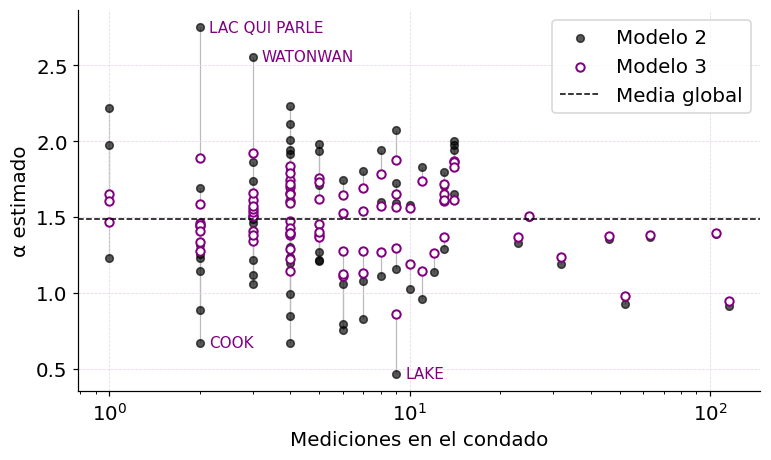

In [25]:
alpha_jer = idata_jerarquico.posterior["alpha"].mean(("chain", "draw")).values
mu_global = float(idata_jerarquico.posterior["mu_alpha"].mean())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.vlines(n_obs, alpha_unpooled, alpha_jer, color="#BBBBBB", linewidth=0.8, zorder=0)
ax.scatter(n_obs, alpha_unpooled, color="black", s=25, alpha=0.65, label="Modelo 2")
ax.scatter(n_obs, alpha_jer, facecolors="white", edgecolors=ACENTO, s=30,
           linewidths=1.3, label="Modelo 3")
for c in extremos:
    ax.annotate(nombres[c], (n_obs[c], alpha_unpooled[c]), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=10, color=ACENTO)
ax.axhline(mu_global, color="black", linestyle="--", linewidth=1, label="Media global")
ax.set_xscale("log")
ax.set_xlabel("Mediciones en el condado")
ax.set_ylabel("α estimado")
ax.legend()
plt.show()

A la izquierda, líneas largas. LAC QUI PARLE baja de 2,7 a 1,9. Los condados con pocas
mediciones se acercan a Minnesota, es decir, si tengo pocos datos de un condado, el modelo hace que se parezca más al Estado en general (al conjunto de todos los condados). A la derecha, casi no hay líneas que muestren diferencias entre el caso 2 y el 3 porque con cien mediciones
el condado se sostiene solo.

El tamaño del tirón sale de dos varianzas del modelo. Una mide cuánto difieren los
condados. La otra, cuánto difieren las casas de un mismo condado.

In [26]:
s_alpha = float(idata_jerarquico.posterior["sigma_alpha"].mean())
s_resid = float(idata_jerarquico.posterior["sigma"].mean())
n_equivalente = (s_resid / s_alpha) ** 2

print(f"σ_alpha (entre condados)   = {s_alpha:.2f}")
print(f"σ       (entre viviendas)  = {s_resid:.2f}")
print(f"Lo que el modelo sabe de Minnesota pesa como {n_equivalente:.0f} mediciones propias.")

σ_alpha (entre condados)   = 0.32
σ       (entre viviendas)  = 0.73
Lo que el modelo sabe de Minnesota pesa como 5 mediciones propias.


Por debajo de ese número manda Minnesota. Por encima manda el condado. Nadie ha elegido
el umbral. Sale de los datos.

## 5. Diagnóstico: ¿ha funcionado el muestreador?

Esto lo debería haber hecho en los otros modelos también, pero he preferido centrarme en resultados antes. Ahora te enseño lo que debeeríamos haber hecho antes de leer cada posteriori.

Primero, la traza. Las cuatro cadenas
deben solaparse.

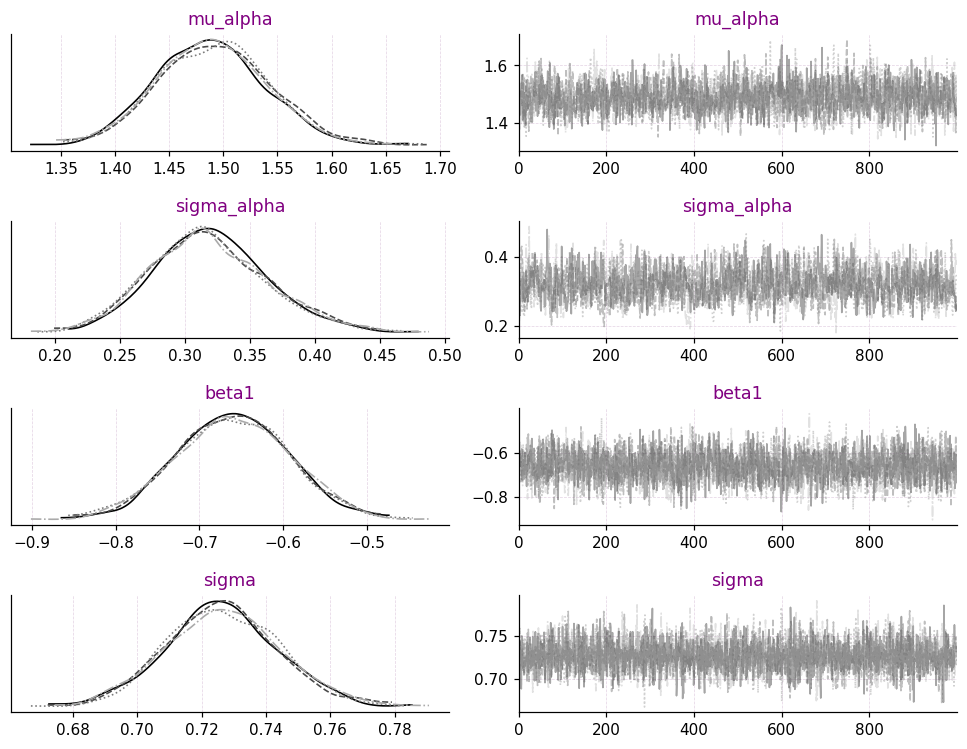

In [27]:
az.plot_trace(
    idata_jerarquico,
    var_names=["mu_alpha", "sigma_alpha", "beta1", "sigma"],
    chain_prop={"color": GRISES, "linestyle": ["-", "--", ":", "-."]},
    figsize=(9, 7),
)
plt.tight_layout()
plt.show()

Después, los números. `r_hat` debe rondar 1. El ESS cuenta muestras efectivas; bastan unos
cientos. Las divergencias deben ser cero.

In [28]:
resumen_jer = az.summary(
    idata_jerarquico, var_names=["mu_alpha", "sigma_alpha", "beta1", "sigma"]
)
n_divergencias = int(idata_jerarquico.sample_stats["diverging"].sum())

print(f"Divergencias: {n_divergencias}")
resumen_jer[["mean", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk", "ess_tail"]]

Divergencias: 0


,mean,hdi_3%,hdi_97%,r_hat,ess_bulk,ess_tail
mu_alpha,1.490,1.395,1.584,1.0,2587.0,3141.0
sigma_alpha,0.319,0.231,0.400,1.0,967.0,1321.0
beta1,-0.660,-0.774,-0.524,1.0,3740.0,3054.0
sigma,0.727,0.692,0.758,1.0,6459.0,3032.0


Todo en orden. Falta ver si el modelo reproduce los datos.

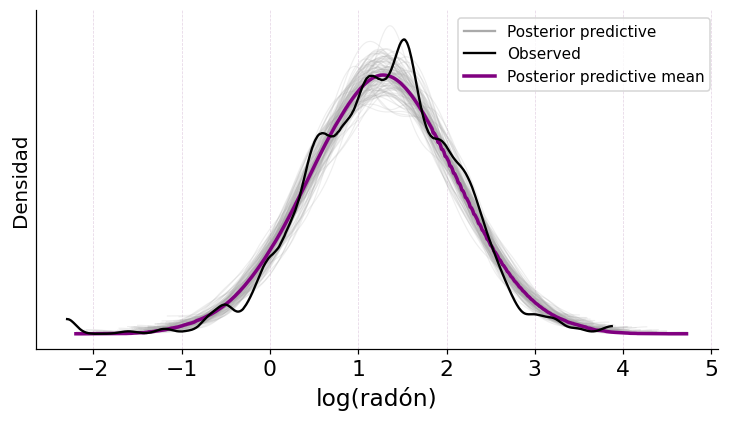

In [29]:
with modelo_jerarquico:
    pm.sample_posterior_predictive(
        idata_jerarquico, extend_inferencedata=True,
        random_seed=SEMILLA, progressbar=False,
    )

ax = az.plot_ppc(
    idata_jerarquico, num_pp_samples=100, random_seed=SEMILLA,
    colors=["#AAAAAA", "black", ACENTO], figsize=(8, 4),
)
for linea in ax.get_lines():
    linea.set_linestyle("-")
ax.set_xlabel("log(radón)")
ax.set_ylabel("Densidad")
ax.legend(fontsize=10)
plt.show()

Las réplicas cubren los datos. Se les escapa un pico cerca de 1. Esto es porque estamos asumiendo normalidad y los datos no lo son.

## 6. La verdadera aplicación. Cómo predecimos un caso suelto

La pregunta es sobre una casa. Dada una casa, ¿qué cantidad de radón se espera? Hay dos respuestas:

- El **nivel del condado**.
- El **nivel de una vivienda**: el del condado más la variación entre casas, $\sigma$.

Comparamos ST LOUIS, con 116 mediciones, y LAC QUI PARLE, con 2. Las dos, midiendo en el
sótano.

In [30]:
post = idata_jerarquico.posterior
s = post["sigma"].values.reshape(-1)


def prediccion(condado):
    # Intervalos al 94 % en pCi/L, para una medición en el sótano (planta = 0).
    c = list(nombres).index(condado)
    mu = post["alpha"].values[:, :, c].reshape(-1)
    y = rng.normal(mu[:, None], s[:, None], size=(len(mu), 20)).reshape(-1)  # 20 casas por muestra

    hdi_condado = np.exp(az.hdi(mu, hdi_prob=0.94))
    hdi_casa = np.exp(az.hdi(y, hdi_prob=0.94))
    return {
        "Condado 3%": hdi_condado[0],
        "Condado 97%": hdi_condado[1],
        "Casa 3%": hdi_casa[0],
        "Casa 97%": hdi_casa[1],
        "P(casa > 4 pCi/L)": (np.exp(y) > 4).mean(),
    }


condados = ["ST LOUIS", "LAC QUI PARLE"]
pd.DataFrame(
    [prediccion(c) for c in condados],
    index=[f"{c} ({(df['county'] == c).sum()} mediciones)" for c in condados],
).round(2)

,Condado 3%,Condado 97%,Casa 3%,Casa 97%,P(casa > 4 pCi/L)
ST LOUIS (116 mediciones),2.27,2.92,0.64,10.16,0.27
LAC QUI PARLE (2 mediciones),3.74,11.19,1.56,29.91,0.74


El intervalo del condado se ensancha en LAC QUI PARLE. De él sabemos poco.

El de la casa es ancho en los dos. Su extremo alto multiplica por 15 o más al bajo. Lo
domina $\sigma$, la variación entre casas. Más mediciones en el condado no lo estrechan.

Conocer el condado no basta. Cada casa se mide.

## Con qué quiero que te quedes

- Juntar y separar son casos extremos del jerárquico.
- Cada caso en bayesiano son pequeñas variaciones en el código.
- La priori se simula antes de ajustar.
- El muestreo se diagnostica antes de leer la posteriori.
- La respuesta es una distribución.

**Para seguir.** Gelman y Hill, *Data Analysis Using Regression and Multilevel/Hierarchical
Models*, de donde salen estos datos. Disponible [aquí](https://github.com/bgse-datascience-group8/Statistical-Modelling-and-Inference/tree/master/resources).

Como libro de estadística, lo considero un referente. Pero para aprender bayesiano desde cero, el _Statistical Rethinking_ Richard McElreath me parece un enfoque más acertado.

---

Esto es el regalo de suscripción de mi newsletter. Escribo sobre estadística y análisis de
datos con más sarcasmo del recomendable: **[leonardohansa.com](https://leonardohansa.com)**.

Las slides del seminario están en
**[lhansa.github.io/seminar-bayes](https://lhansa.github.io/seminar-bayes/)**.

Si ejecutas esto, lo rompes o lo mejoras, cuéntamelo respondiendo a cualquier correo.